# Midterm Assessment: Student Exam Performance
**Name:** Harrison Christophersen  

# Part 1: Audience Focused Executive Summary

## Purpose
I was asked to analyze exam results for 1,000 students and explain what
separates higher performers from lower ones. The aim is to give decision makers a clear
picture of where extra support would help most. I looked at three subjects alongside background
details such as gender, parental education, whether a student completed a test
preparation course, and which lunch program they were on.

## What I found
Three patterns stand out.
First, preparation pays off. Students who completed the test preparation course scored higher
in every subject, about 7.6 points higher on average. This is encouraging, because it is
something a school can directly influence.
Second, economic background appears to matter even more. Students on the standard lunch
program scored about 8.6 points higher than students on the free or reduced lunch program,
the largest gap I found. Lunch status is commonly used as an indicator of household income,
so this gap likely reflects financial circumstances at home rather than anything about the
students ability. The gap was widest in math.
Third, reading and writing go hand in hand. A student who reads well almost always writes
well; the two scores rise and fall together almost perfectly. Math is related too, but a
little more independent. Gender differences were smaller and depended on the subject: girls
scored higher in reading and writing, while boys scored slightly higher in math.

## Recommendations
- Expand access to the test preparation course, since it helped across every subject and is within the school's control.
- Direct additional academic support toward students on the free or reduced lunch program, where the largest gap appears, recognizing that some of this support may need to address needs outside the classroom.
- Treat reading and writing as a single literacy focus, because improving one tends to lift the other, which makes support more efficient.

# Part 2: Exploratory Data Analysis

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [ ]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## The columns
- gender - female or male
- race/ethnicity - anonymized group label (A to E)
- parental level of education - highest education of a parent
- lunch - standard, or free/reduced (a common stand-in for household income)
- test preparation course - completed or none (our stand-in for study habits)
- math / reading / writing score - exam results from 0 to 100

In [ ]:
df.info()
print()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: in

The dataset has no missing values, next we rename the
columns to remove spaces and slashes, and we create a single
`average_score` column to summarize each student with one number.

In [ ]:
df = df.rename(columns={
    "race/ethnicity": "race_ethnicity",
    "parental level of education": "parental_education",
    "test preparation course": "test_prep",
    "math score": "math",
    "reading score": "reading",
    "writing score": "writing",
})

df["average_score"] = df[["math", "reading", "writing"]].mean(axis=1)
df.head()

,gender,race_ethnicity,parental_education,lunch,test_prep,math,reading,writing,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


## Summary statistics

In [ ]:
df.describe()

,math,reading,writing,average_score
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,67.770667
std,15.16308,14.600192,15.195657,14.257326
min,0.00000,17.000000,10.000000,9.000000
25%,57.00000,59.000000,57.750000,58.333333
50%,66.00000,70.000000,69.000000,68.333333
75%,77.00000,79.000000,79.000000,77.666667
max,100.00000,100.000000,100.000000,100.000000


In [ ]:
for col in ["math", "reading", "writing", "average_score"]:
    print(col)
    print("  mean    ", round(df[col].mean(), 2))
    print("  median  ", round(df[col].median(), 2))
    print("  variance", round(df[col].var(), 2))

math
  mean     66.09
  median   66.0
  variance 229.92
reading
  mean     69.17
  median   70.0
  variance 213.17
writing
  mean     68.05
  median   69.0
  variance 230.91
average_score
  mean     67.77
  median   68.33
  variance 203.27


Average scores sit in the high 60s. Medians are almost identical to the means, so the scores are fairly symmetric
rather than skewed. Writing and math show the widest spread, while the
combined average is the most stable because averaging three subjects
smooths out individual swings.

## Chart 1: Categorical comparison
Does completing the test preparation course relate to higher scores?

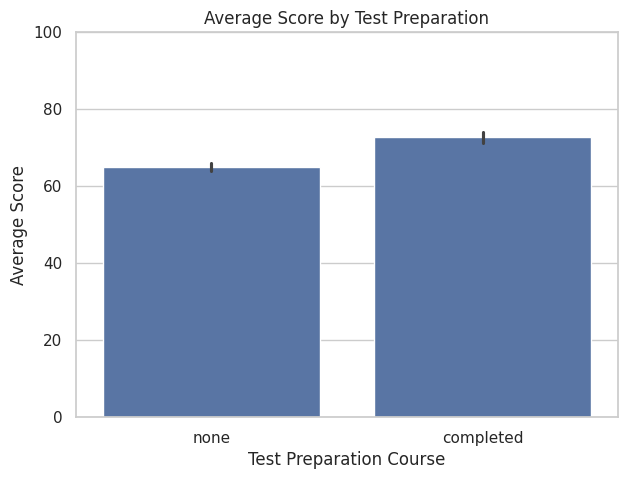

In [ ]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x="test_prep", y="average_score")
plt.title("Average Score by Test Preparation")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")
plt.ylim(0, 100)   # honest baseline at zero
plt.show()

Students who completed the preparation course average about 72.7,
versus65.0 for those who did not, a gap of roughly 7.6 points. The gain holds in
every subject and is largest in writing. The y-axis starts at zero so the bar heights
represent the scores honestly.

## Chart 2: Distribution
How are overall scores spread across all students?

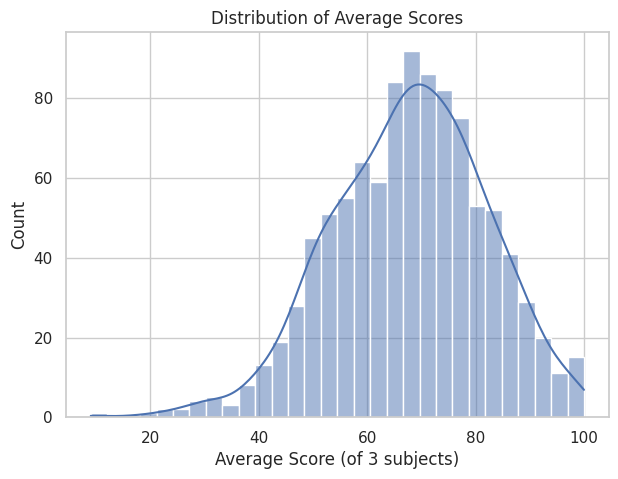

In [ ]:
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x="average_score", kde=True, bins=30)
plt.title("Distribution of Average Scores")
plt.xlabel("Average Score (of 3 subjects)")
plt.show()

The distribution is roughly bell-shaped and centered near 68, with
most students between about 55 and 80. A thin left tail shows a small number of low
performers, which is where targeted support would matter most.

## Chart 3: Relationship
Do reading and writing scores move together?


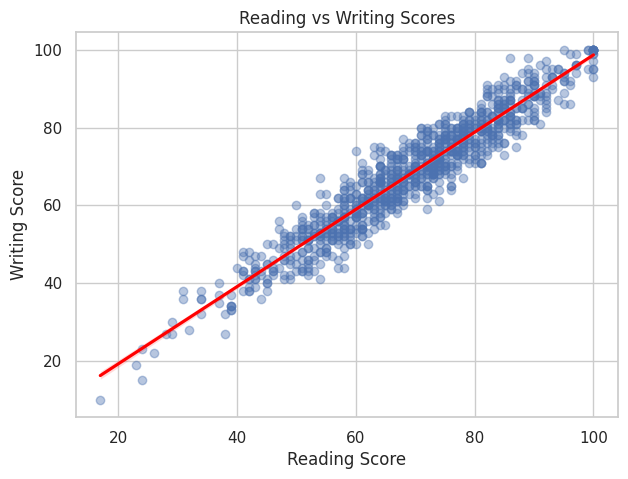

In [ ]:
plt.figure(figsize=(7, 5))
sns.regplot(data=df, x="reading", y="writing",
            scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
plt.title("Reading vs Writing Scores")
plt.xlabel("Reading Score")
plt.ylabel("Writing Score")
plt.show()

In [ ]:
df[["math", "reading", "writing"]].corr().round(3)

,math,reading,writing
math,1.000,0.818,0.803
reading,0.818,1.000,0.955
writing,0.803,0.955,1.000


Reading and writing are very strongly correlated, so a
student strong in one is almost always strong in the other. Math is also strongly related to
both but a little more independent. In practice, reading and writing partly
measure the same underlying literacy skill.

## Chart 4: Score by lunch program

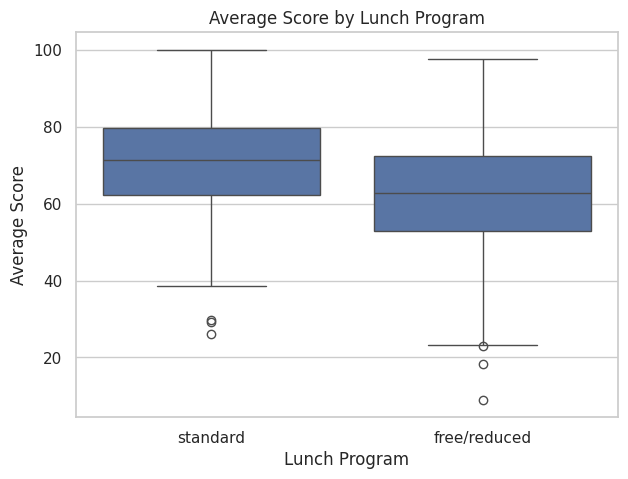

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="lunch", y="average_score")
plt.title("Average Score by Lunch Program")
plt.xlabel("Lunch Program")
plt.ylabel("Average Score")
plt.show()

Students on the standard lunch average about 70.8, versus 62.2
for those on free or reduced lunch, a gap of roughly 8.6 points, the largest of any
factor here. The gap is widest in math (about 11 points). Because lunch status reflects
economic background, this points to support being needed beyond the classroom.

# Part 3: Visualization Critique

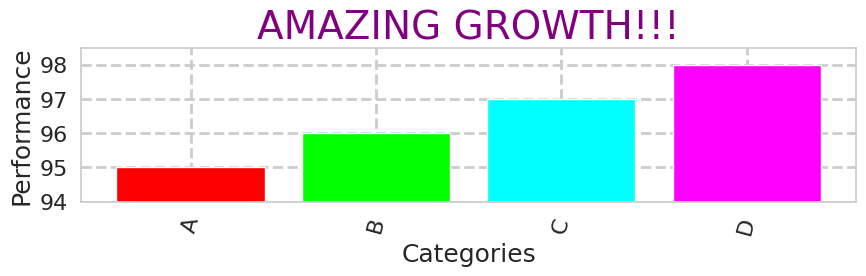

In [ ]:
# Fake data
categories = ['A', 'B', 'C', 'D']
values = [95, 96, 97, 98]

# Terrible chart
plt.figure(figsize=(10, 2))

plt.bar(categories, values,
        color=['red', 'lime', 'cyan', 'magenta'])

# Misleading axis
plt.ylim(94, 98.5)

# Bad styling choices
plt.title("AMAZING GROWTH!!!", fontsize=28, color='purple')
plt.xlabel("Categories", fontsize=18)
plt.ylabel("Performance", fontsize=18)

# Hard-to-read grid
plt.grid(True, linestyle='--', linewidth=2)

# Rotate labels unnecessarily
plt.xticks(rotation=75, fontsize=16)
plt.yticks(fontsize=16)

plt.show()

## What makes this visualization misleading
The biggest problem is the y-axis. It starts at 94 instead of 0, so values that differ by
only about one percent (95 to 98) appear to differ enormously; the last bar looks several
times taller than the first when the four values are nearly identical. The title, AMAZING
GROWTH, makes things worse by announcing a conclusion the data does not support and adding
emphasis that has no place on a chart. The four neon colors carry no meaning, since the
categories are not ranked or grouped.

## Which visualization principles are violated
- A bar's length should be proportional to its value, which truncating the axis breaks directly.
- The thick dashed gridlines and oversized fonts are clutter that competes with the data.
- The chart editorializes through its title instead of letting the reader judge.
- Rotating the labels 75 degrees and using arbitrary colors makes the chart harder to read for no analytical reason.

## How I would redesign it
I would start the y-axis at 0 so the bars tell the truth about magnitude, use a single muted
color since the categories need no color coding, replace the title with a neutral description
such as Performance by Category, set the labels horizontal, and remove the heavy gridlines.


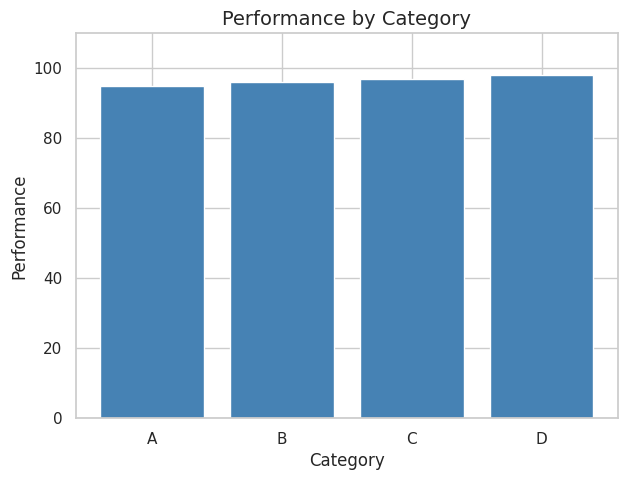

In [ ]:
categories = ['A', 'B', 'C', 'D']
values = [95, 96, 97, 98]

plt.figure(figsize=(7, 5))
plt.bar(categories, values, color="steelblue")
plt.ylim(0, 110)                        # honest baseline at zero
plt.title("Performance by Category", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Performance")
plt.show()

# Part 4: Technical Report

## Introduction
Schools want to understand which factors are associated with stronger exam performance so
they can target limited support effectively. This report analyzes a dataset of 1,000
students, each with scores in three subjects (math, reading, and writing) and several
background attributes: gender, race/ethnicity (anonymized), parental level of education,
lunch program status, and whether the student completed a test preparation course. The
question I set out to answer is which of these factors relate most clearly to performance,
and what a school might do in response.

## Methods
Data preparation. I loaded the dataset and confirmed it contained no missing values, so
no imputation was needed. I renamed the columns to remove spaces and slashes for cleaner
code, and I created an `average_score` column equal to the mean of the three subject scores,
giving one summary measure per student.

Analysis approach. I computed summary statistics (mean, median, and variance) for each
subject and for the combined average. I then examined the data through four chart types: a
categorical comparison (average score by test preparation), a distribution (the spread of
average scores), a relationship (reading versus writing), and a correlation view, plus an
additional chart for gender. All work was
done in Python using pandas, seaborn, and matplotlib.

## Results
Summary statistics show average scores in the high 60s (math 66.1, reading 69.2, writing
68.1) with medians almost equal to the means, showing roughly symmetric distributions.
The categorical comparison (Chart 1) shows students who completed the test preparation course
averaging 72.7 against 65.0 for those who did not, a difference of about 7.6 points that
holds across all three subjects. The distribution (Chart 2) is approximately bell-shaped and
centered near 68, with a thin left tail of low performers. The relationship chart (Chart 3)
and the correlation table show reading and writing are very strongly correlated (r = 0.96),
while math correlates with each at about 0.80. The lunch comparison (Chart 4) reveals the
largest gap in the data: standard-lunch students average 70.8 versus 62.2 for free or reduced
lunch, a difference of about 8.6 points, widest in math.

## Discussion
Two factors stand out as most associated with performance: lunch program status and test
preparation. Because lunch status is a standard proxy for household income, its large effect
suggests that economic circumstances outside school weigh heavily on results, particularly in
math. Test preparation, by contrast, is something the school controls directly, and its
consistent benefit across subjects makes it an appealing lever. The very high correlation
between reading and writing implies the two are partly measuring the same underlying literacy
skill, so they can be supported together. Throughout, it is important to stress that these
are observational associations. The data cannot establish cause, and unmeasured factors
(school quality, home environment, prior achievement) may drive several of these patterns at
once.

## Conclusion
The analysis points to three actions: expand the test preparation course, since it helps
every subject and lies within the school's control; focus additional support on students on
the free or reduced lunch program, where the largest gap appears; and treat reading and
writing as a combined literacy effort. These recommendations should be read as informed
starting points for targeted follow-up, not as proven cause-and-effect relationships.

# Part 5: Ethics Reflection

Visualizations can mislead an audience even when no one intends to deceive. The most common
way is the axis: starting a bar chart above zero, as in the chart I critiqued in Part 3,
makes small differences look dramatic. Choosing a narrow range, cropping a time series, or
stretching one axis can manufacture a trend that is not there. Aggregation is another quiet
source of error. Combining everyone into a single average can hide important subgroups, and a
pattern that holds for the whole group can even reverse within a subgroup. Color can imply meaning that does not exist, for example red suggesting
danger, and common red-green palettes exclude colorblind readers. Leaving out sample sizes or
any sense of uncertainty makes a fragile result look solid, and placing a strong title next
to a correlation nudges viewers to assume one thing caused another.

Because of all this, analysts carry a clear responsibility when they present results. I see a
few obligations. First, encode data honestly: use proportional baselines so that visual size
matches actual magnitude. Second, provide context, including how many observations there are,
what time period is covered, and what a variable actually measures. In this project, for
example, lunch status is a stand-in for income, not a judgment about a student, and saying
so plainly matters. Third, separate evidence from recommendation, and label associations as
associations rather than dressing them up as proof. Fourth, design for the actual audience: a
non-technical reader will take a chart at face value, so the burden of accuracy sits with the
analyst, not the viewer. Finally, disclose limitations openly instead of hoping no one asks.
The underlying principle is simple: since the audience usually cannot inspect the data or the
code behind a chart, the analyst's job is to make the honest reading the easiest one to
reach.

# Part 6: Challenge Questions

## Which variable appears most influential in explaining the outcome?
Of the factors I examined, lunch program status shows the largest association with
performance: an 8.6 point gap in average score, and roughly an 11 point gap in math
specifically. Test preparation is close behind at about 7.6 points. I would therefore name
lunch status as the most influential observable factor, with the important qualification that
lunch is a proxy for household income, so it is standing in for economic circumstances rather
than causing scores by itself. This is also a comparison of group averages from charts, not a
ranked importance from a formal model, so it indicates where to look first rather than a
precise ordering.

## What limitations exist in your analysis?
Several. The dataset has no direct measure of study time, so test preparation (completed or
not) is only a rough stand-in for study habits. The data is observational, which means I can
describe associations but cannot prove causation, and important factors such as school
quality, prior achievement, and home environment are not measured. The scores cover only
three subjects at a single point in time, so there is no view of progress or long-term
outcomes. Finally, the dataset's origin and sampling method are not documented, which limits
how confidently the findings can be generalized to other schools.
